In [10]:
import Functional_Fusion.reliability as rel
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetLanguage
import os
from OptimalBattery.global_config import data_path,save_dir
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import OptimalBattery.util as ut
from scipy.stats import pearsonr


In [11]:
# define atlas and dirs
space = 'fs32k'
atlas,_= am.get_atlas(atlas_str=space)

  
# Load data
MDTB_dataset = DataSetLanguage(f'{data_path}/FunctionalFusion_new/Language')

subj = ['sub-02','sub-04','sub-06','sub-07','sub-08','sub-09','sub-10','sub-12','sub-13','sub-14','sub-15','sub-16','sub-17','sub-18','sub-19']


data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-localizer',type='CondRun',subj=subj)
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0

mask = ~info_mdtb_1_run["cond_code"].isin(["sentence", "noword"])
info_mdtb_1_run = info_mdtb_1_run[mask].copy()
data_mdtb_s1_run = data_mdtb_s1_run[:,mask.values, :]

info_mdtb_1_run["cond_num"] = (
    info_mdtb_1_run.groupby("run").cumcount() + 1
)

# Reset index for cleanliness
info_mdtb_1_run.reset_index(drop=True, inplace=True)



In [12]:
n_cond = info_mdtb_1_run['cond_num'].nunique()
print(f'Number of conditions: {n_cond}')

n_part = info_mdtb_1_run['run'].nunique()
print(f'Number of partitions: {n_part}')

Number of conditions: 16
Number of partitions: 8


In [13]:
cond_vec = np.tile(np.arange(1, n_cond + 1), n_part)
part_vec = np.repeat(np.arange(1, n_part + 1), n_cond)


In [14]:
var = rel.decompose_subj_group(data_mdtb_s1_run, cond_vec, part_vec,separate='subject_wise',subtract_mean= False)
combined = (var[:, 0] + var[:, 1]).tolist()
print(combined)

[0.041881832156150475, 0.014676254895000344, 0.025045466402642325, 0.04423679977057912, 0.038261696093508844, 0.020414259362058505, 0.022589327170711593, 0.03108952781138235, 0.03647954545652632, 0.0372114594991406, 0.020185820335720008, 0.036755042677682544, 0.0389223872248475, 0.030486533932167735, 0.036219257902754494]


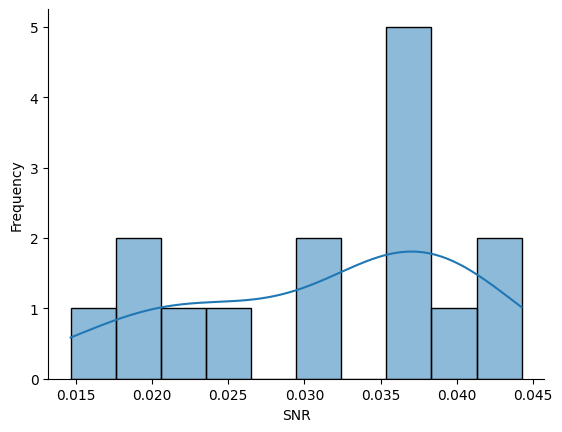

In [16]:
snr_list = combined
sns.histplot(snr_list, bins=10, kde=True)
plt.xlabel("SNR")
plt.ylabel("Frequency")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# save
plt.savefig(f"{save_dir}/single_vs_multi_real/language_snr_hist.pdf", bbox_inches='tight')
plt.show()

# check localizer size

In [17]:
data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-localizer',type='CondRun',subj=subj)
data_mdtb_s1_run = ut.recenter_fmri_data(data_mdtb_s1_run,info_mdtb_1_run,task_column_name='task_name',center_condition='rest')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0

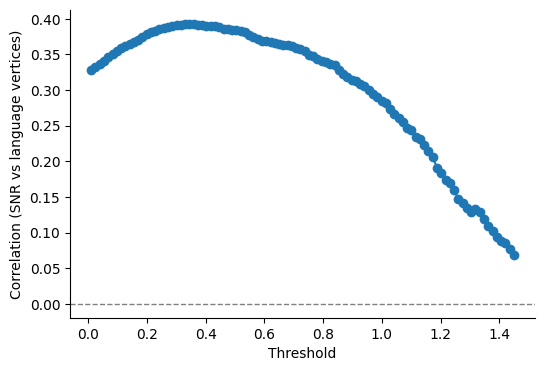

In [19]:
# define thresholds to test
thresholds = np.linspace(0.01, 1.45, 100) 

r_values = []
p_values = []

for thr in thresholds:
    active_vox = []
    for i in range(len(combined)):
        subject_data = data_mdtb_s1_run[i, :, :]

        # your contrast: Sentence - Nonword
        sentence_data = subject_data[16, :]
        nonword_data = subject_data[17, :]
        contrast = sentence_data - nonword_data

        # threshold and count active voxels
        mask = np.where(contrast > thr, 1, 0)
        n_active_voxels = np.sum(mask)
        active_vox.append(n_active_voxels)

    # correlation between SNR and number of active voxels
    r, p = pearsonr(combined, active_vox)
    r_values.append(r)
    p_values.append(p)

plt.figure(figsize=(6,4))
plt.plot(thresholds, r_values, marker='o', label='r (correlation)')
plt.xlabel('Threshold')
plt.ylabel('Correlation (SNR vs language vertices)')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.savefig(f"{save_dir}/single_vs_multi_real/language_snrSizeCorr_vs_threshold.pdf", bbox_inches='tight')
plt.show()
